{0: 'blog.csdn', 1: 'xiaohongshu.com', 2: 'bilibili.com', 3: 'zhihu.com', 4: 'douban.com', 5: 'ifeng.com', 6: 'v.qq.com', 7: 'jd.com', 8: 'news.cn', 9: 'qq.com', 10: 'souhu.com', 11: 'taobao', 12: 'tieba.baidu.com', 13: 'toutiao.com', 14: 'youku.com', 15: 'vip.com', 16: 'goofish.com'}


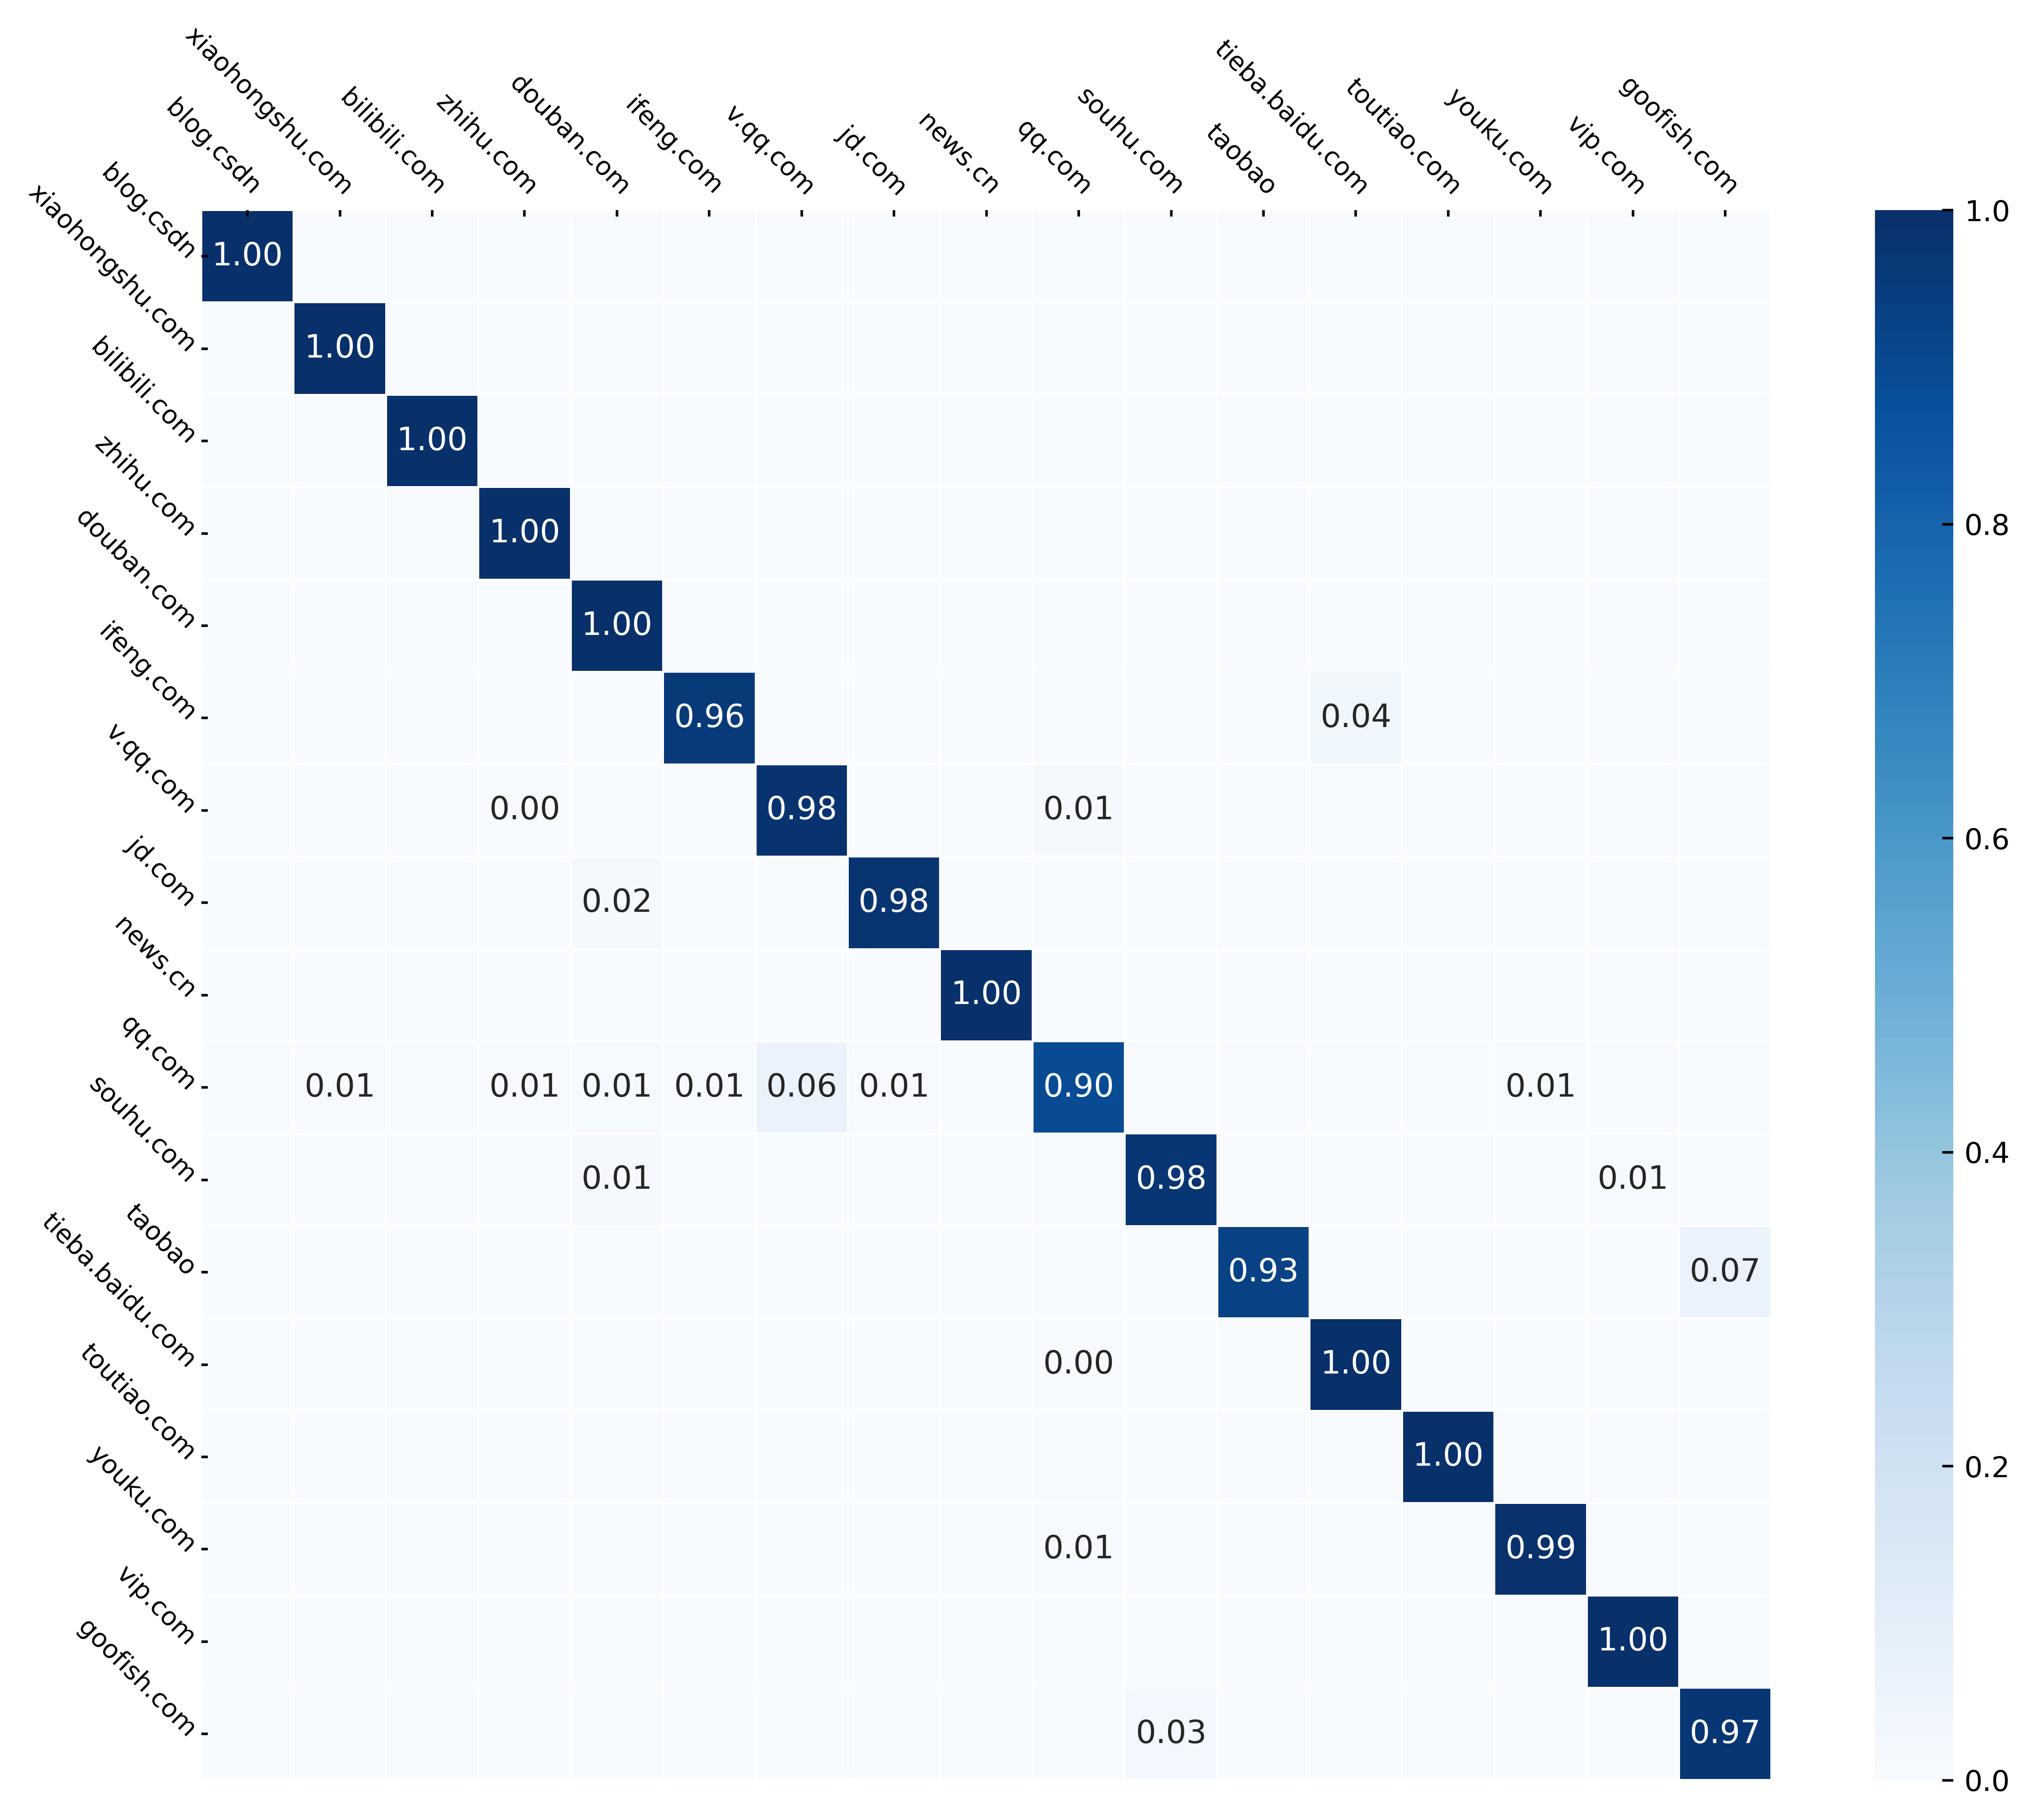

In [11]:
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import os


# Fig.1 全模块的混淆矩阵
# ===========================
# 已知 y_true / y_pred
# ===========================

# get class name
REMOTE_RAW_DATA_DIR = "/home/tyf/fnnas/Study/Traffic-data/train_raw_data"
dirs = os.listdir(REMOTE_RAW_DATA_DIR)
website_name = {}
website_idx = 0
for dir_name in dirs:
    website_name[website_idx] = dir_name
    website_idx += 1

print(website_name)

root_dir = "/home/tyf/Project/Tantic/raw_feature/stgc_sp_all_class_tls_3/result"
y_true = np.load(f"{root_dir}/fusion_y_true.npy")
y_pred = np.load(f"{root_dir}/fusion_y_pred.npy")
class_names = [website_name[i] for i in range(17)]  # TODO: 按需修改类别名

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# 隐藏 0.00 标注
annot_labels = np.where(cm_norm == 0, "", np.vectorize(lambda x: f"{x:.2f}")(cm_norm))

# 提升清晰度：更高 DPI + 更大字体
plt.figure(figsize=(10, 8), dpi=500)
ax = sns.heatmap(
    cm_norm,
    cmap="Blues",
    annot=annot_labels,
    fmt="",
    cbar=True,
    square=True,
    linewidths=0.3,
    linecolor="white",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 10},
)

# 把 X 轴标签放到上方
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# 让 X 标签以起点对齐并锚定
ax.set_xticklabels(class_names, rotation=-45, ha="right", rotation_mode="anchor")
ax.set_yticklabels(class_names, rotation=-45, ha="right", rotation_mode="anchor")

# 隐藏刻度线并增加间距
ax.tick_params(axis="both", length=2)
ax.tick_params(axis="x", pad=3, labelsize=8)
ax.tick_params(axis="y", pad=3, labelsize=8)

# ax.set_title("Normalized Confusion Matrix", fontsize=14)

plt.tight_layout()
plt.show()

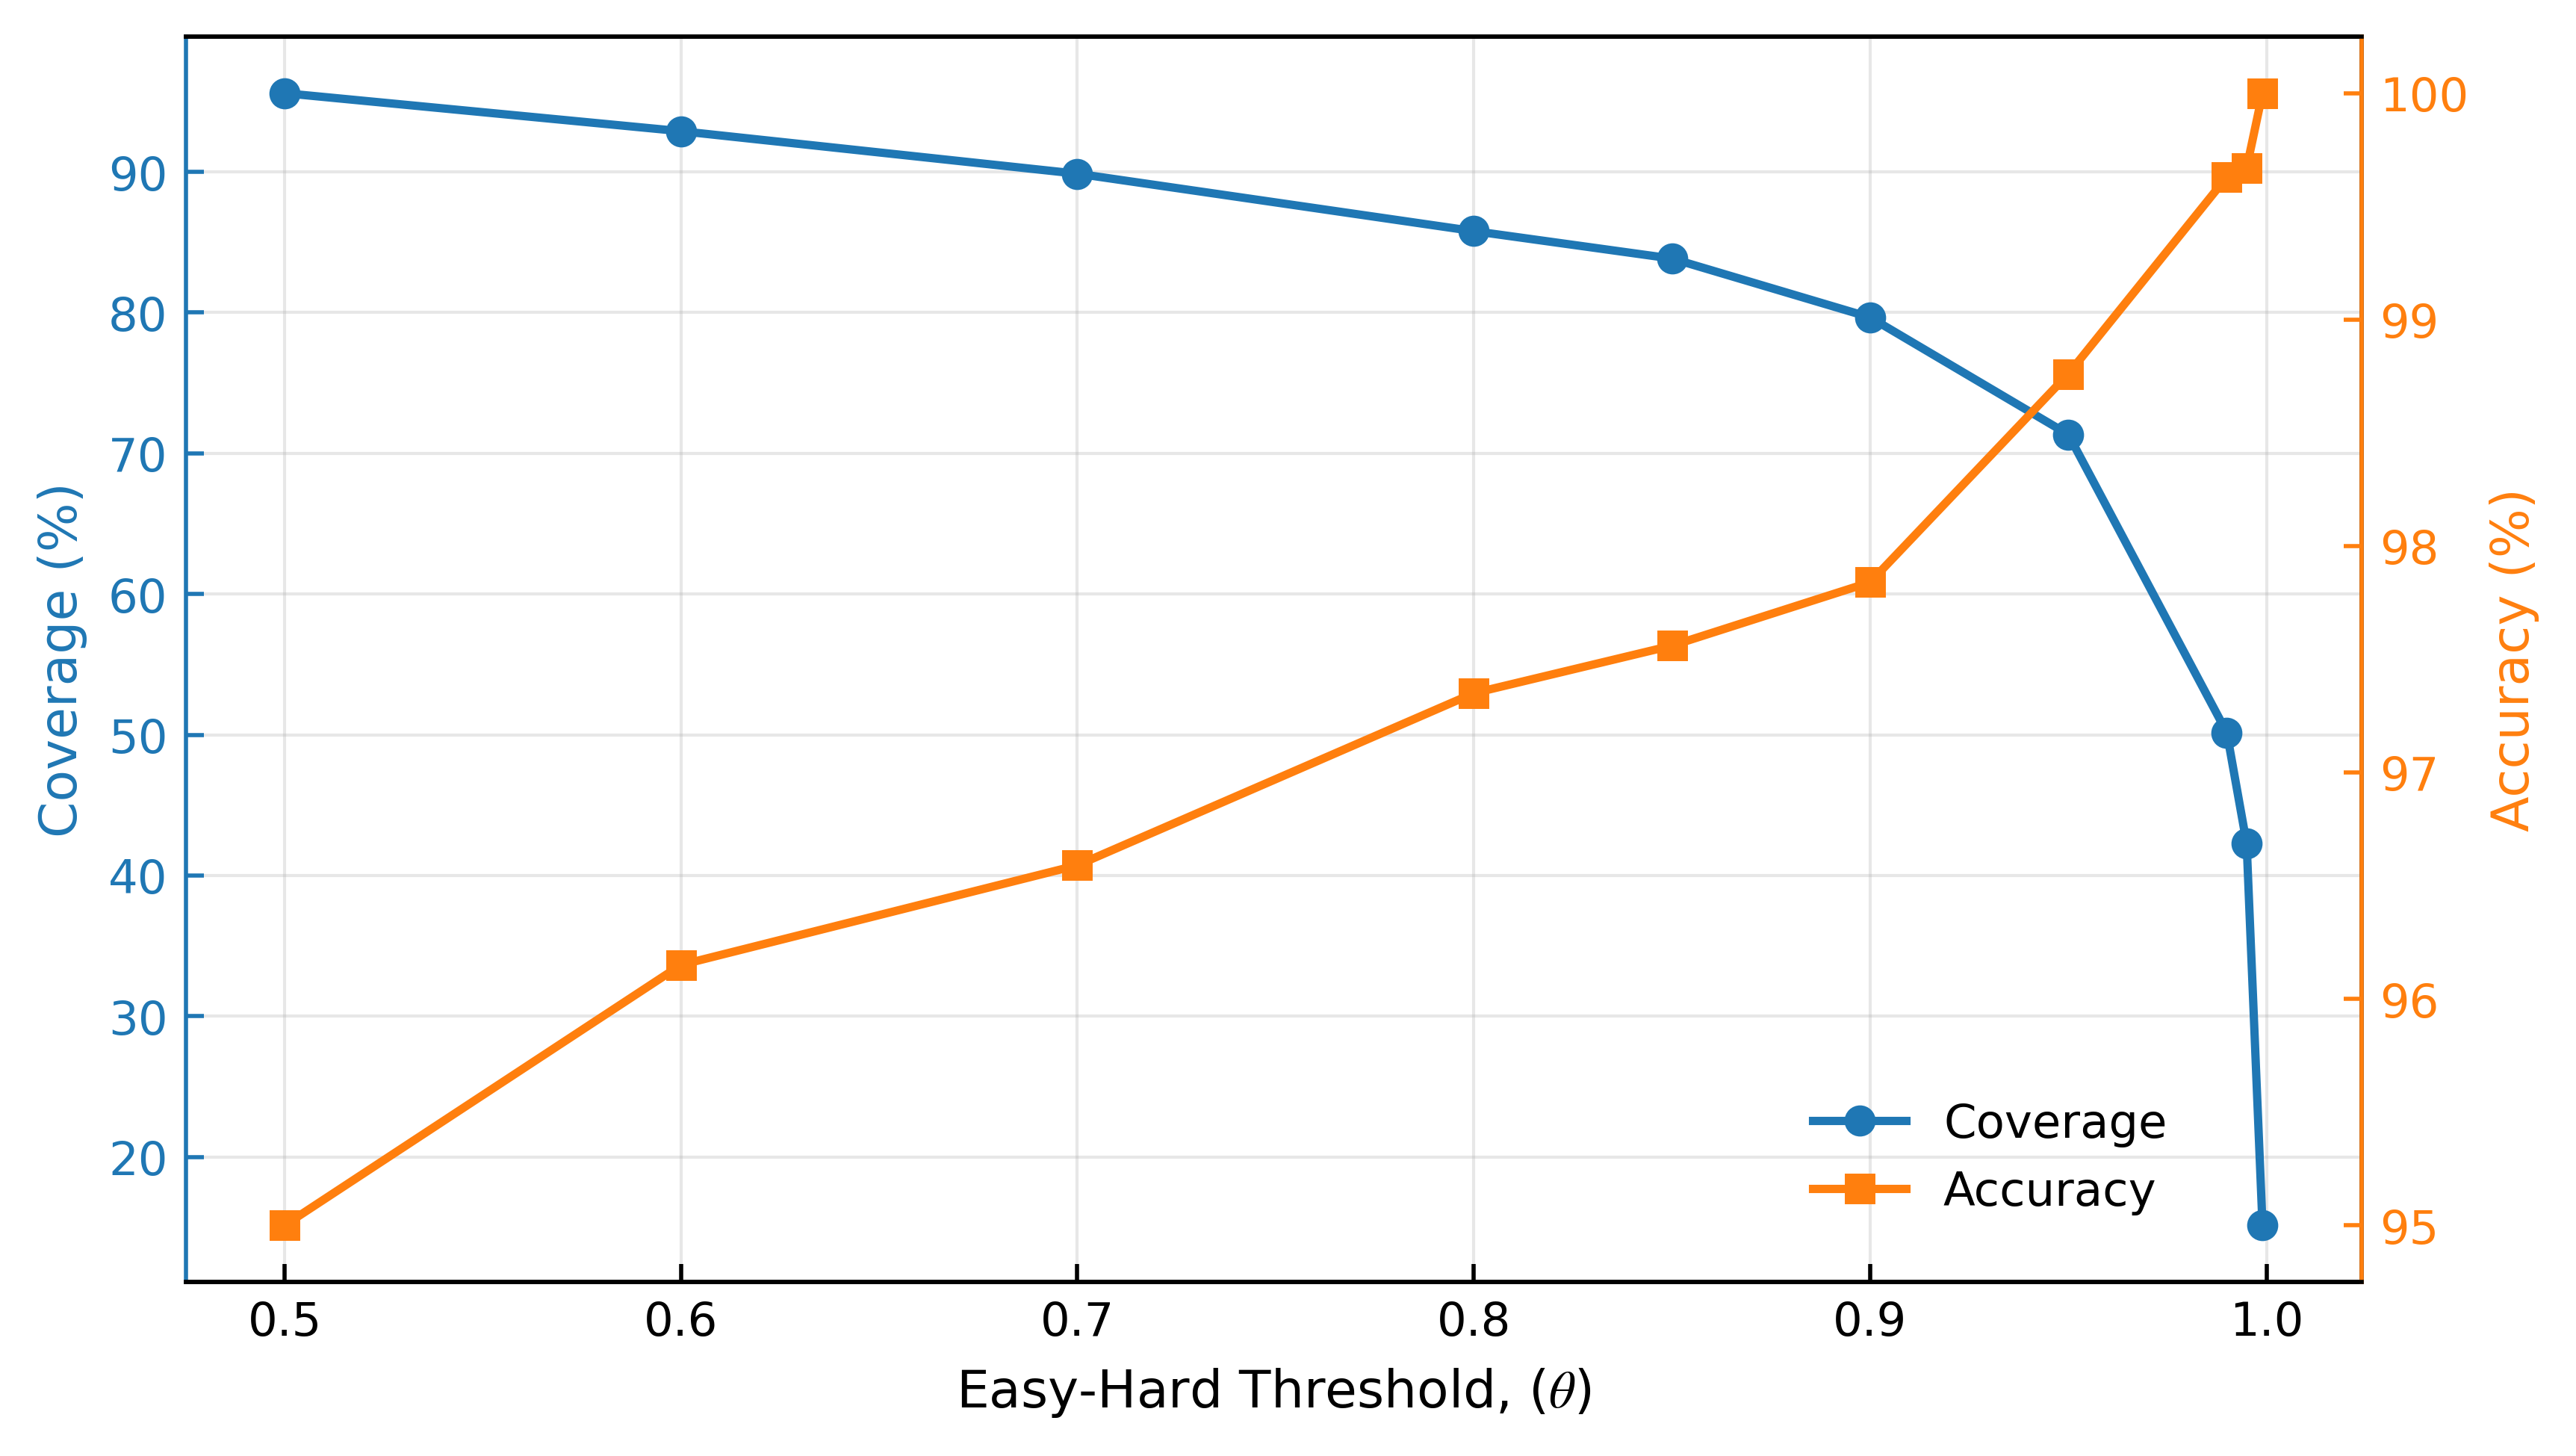

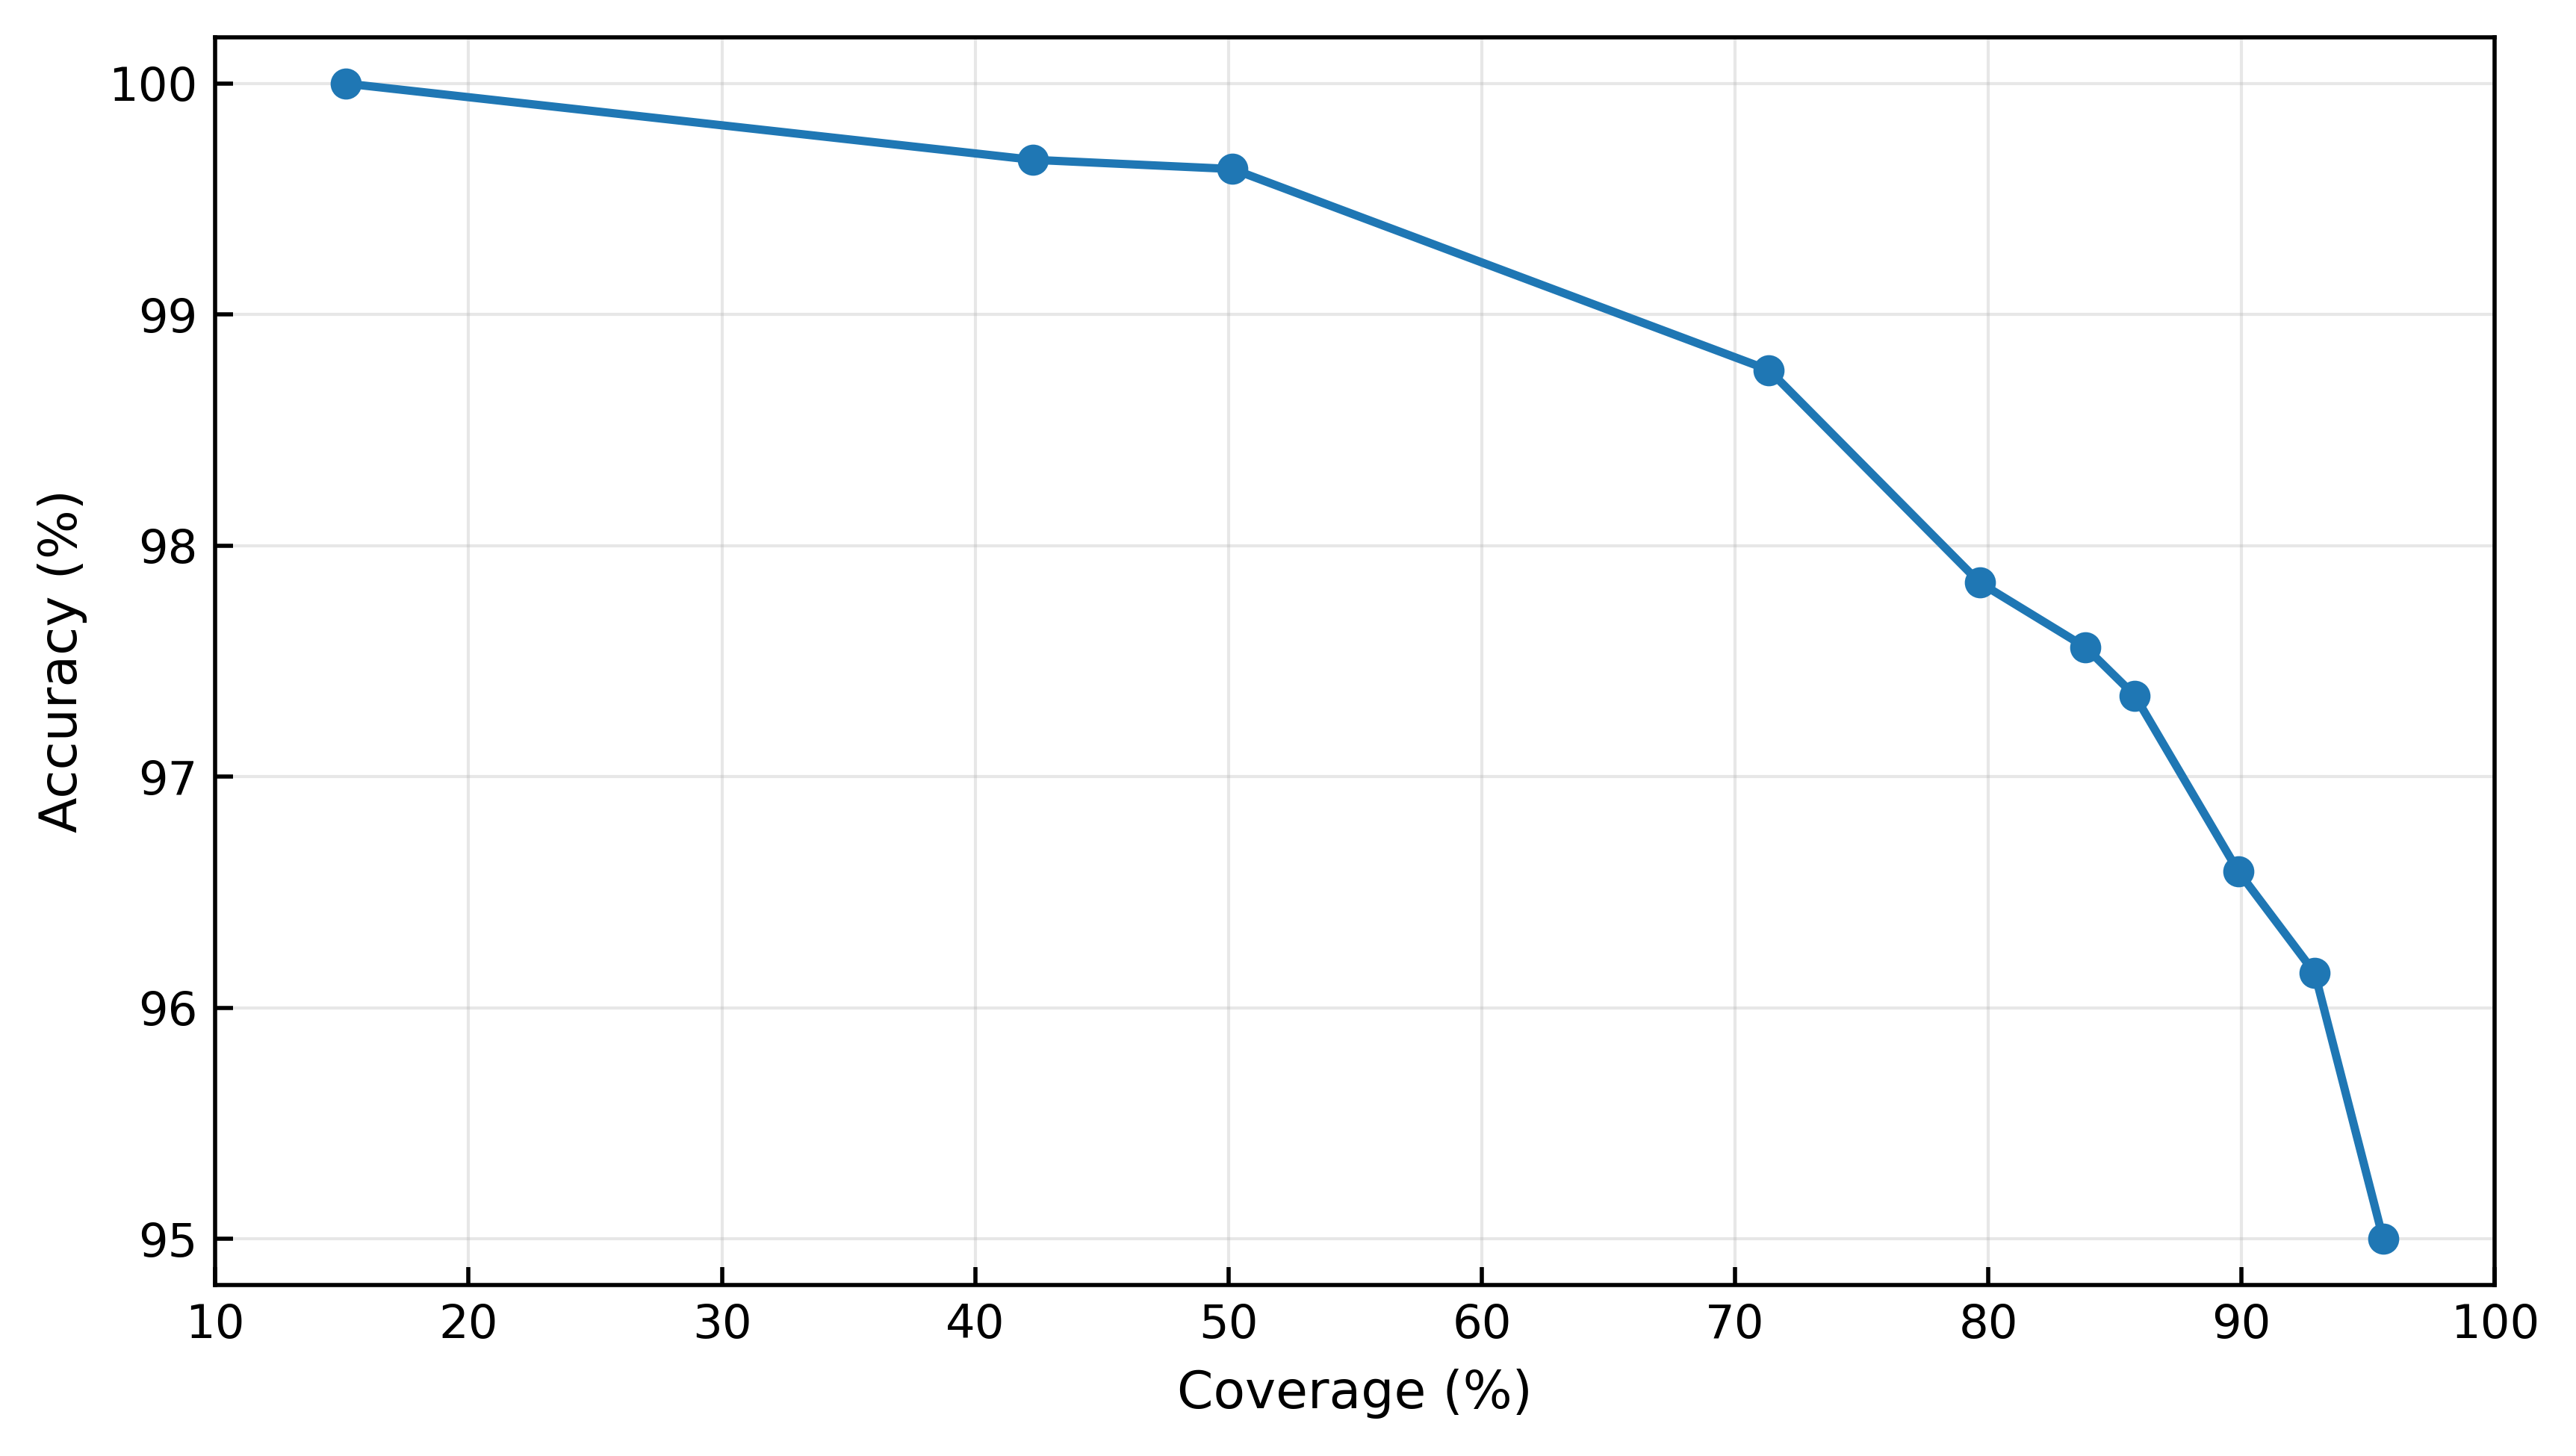

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np


save_dir = "/home/tyf/Project/Tantic/results"
# Fig.2 早期识别模型的阈值与 Cov. 以及 Acc. 的关系

# 这里数据是从 src/models/mfts/analyze_tls_confidence.py 运行结果粘贴而来
# ======================================================================
# TLS Model Performance by Confidence Threshold
# ======================================================================
# Threshold    Coverage     Accuracy     Correct
# ----------------------------------------------------------------------
# 0.500        95.59%       0.9500       1955/2058
# 0.600        92.89%       0.9615       1923/2000
# 0.700        89.87%       0.9659       1869/1935
# 0.800        85.79%       0.9735       1798/1847
# 0.850        83.84%       0.9756       1761/1805
# 0.900        79.66%       0.9784       1678/1715
# 0.950        71.34%       0.9876       1517/1536
# 0.990        50.16%       0.9963       1076/1080
# 0.995        42.27%       0.9967       907/910
# 0.999        15.14%       1.0000       326/326
# ----------------------------------------------------------------------
# ======================================================================
# Low Confidence Samples Analysis
# ======================================================================
# Samples with confidence < 0.99: 1073 (49.84%)
# TLS accuracy on these: 0.8639
# Confidence distribution:
#   Min:    0.2583
#   25%:    0.7592
#   Median: 0.9358
#   75%:    0.9705
#   Max:    0.9900

# ======================================================================
# Conclusion
# ======================================================================
# Overall TLS accuracy: 0.9303
# High confidence (≥0.99) TLS accuracy: 0.9963

# → Two-stage benefits:
#   1. 50.2% samples use fast TLS branch (high accuracy)
#   2. 49.8% samples use fusion (correcting TLS errors)
thresholds = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99, 0.995, 0.999]
coverage = [
    0.9559,
    0.9289,
    0.8987,
    0.8579,
    0.8384,
    0.7966,
    0.7134,
    0.5016,
    0.4227,
    0.1514,
]
accuracy = [0.95, 0.9615, 0.9659, 0.9735, 0.9756, 0.9784, 0.9876, 0.9963, 0.9967, 1.0]

# 论文常用字体与字号（可按期刊要求调整）
plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "mathtext.fontset": "stix",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "lines.linewidth": 1.6,
        "lines.markersize": 5,
        "axes.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
    }
)
plt.rcParams["figure.dpi"] = 500  # 屏幕显示
plt.rcParams["savefig.dpi"] = 300  # 保存图片

# y 轴显示为百分数但不加 %
percent_no_sign = FuncFormatter(lambda v, _: f"{v*100:.0f}")

# 1) 双轴图
fig, ax1 = plt.subplots(figsize=(7, 4))
(line1,) = ax1.plot(
    thresholds, coverage, marker="o", color="tab:blue", label="Coverage"
)
ax1.set_xlabel(r"Easy-Hard Threshold, ($\theta$)")
ax1.set_ylabel(r"Coverage (%)", color="tab:blue")
ax1.yaxis.set_major_formatter(percent_no_sign)
ax1.tick_params(axis="y", colors="tab:blue", labelcolor="tab:blue")
ax1.spines["left"].set_color("tab:blue")
ax1.grid(True, alpha=0.3, linewidth=0.6)

ax2 = ax1.twinx()
(line2,) = ax2.plot(
    thresholds, accuracy, marker="s", color="tab:orange", label="Accuracy"
)
ax2.set_ylabel(r"Accuracy (%)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.yaxis.set_major_formatter(percent_no_sign)
ax2.spines["right"].set_color("tab:orange")
ax2.tick_params(axis="y", colors="tab:orange")
ax2.spines["left"].set_visible(False)
ax1.spines["left"].set_color("tab:blue")
ax1.tick_params(axis="y", colors="tab:blue", labelcolor="tab:blue")

ax1.legend(
    handles=[line1, line2],
    loc="lower right",
    bbox_to_anchor=(0.93, 0.02),
    frameon=False,
)

# plt.title("TLS: Threshold vs Coverage & Accuracy")
plt.tight_layout()
plt.show()

# plt save pdf
fig.savefig(
    f"{save_dir}/tls_threshold_coverage_accuracy_dual_axis.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)


# 2) Accuracy vs Coverage（点标签是阈值 θ，不是坐标轴数值）
coverage_pct = np.array(coverage) * 100
accuracy_pct = np.array(accuracy) * 100
thresholds_arr = np.array(thresholds)

# 按 x 轴升序绘制
order = np.argsort(coverage_pct)
x = coverage_pct[order]
y = accuracy_pct[order]
t = thresholds_arr[order]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, marker="o", color="tab:blue")

# 固定坐标范围，减少视觉误判
ax.set_xlim(10, 100)
ax.set_xticks(np.arange(10, 101, 10))
ax.set_ylim(94.8, 100.2)
ax.set_yticks(np.arange(95, 101, 1))

for i, (xi, yi, ti) in enumerate(zip(x, y, t)):
    # label = f"θ={ti:.3f}".rstrip("0").rstrip(".")
    label = ""
    y_offset = -12 if i % 2 == 0 else -22
    ax.annotate(
        label,
        (xi, yi),
        textcoords="offset points",
        xytext=(0, y_offset),
        ha="center",
        va="top",
        fontsize=8,
    )


ax.set_xlabel("Coverage (%)")
ax.set_ylabel("Accuracy (%)")
ax.grid(True, alpha=0.3, linewidth=0.6)
plt.tight_layout()
plt.show()

# plt save pdf
fig.savefig(
    f"{save_dir}/tls_threshold_coverage_accuracy.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

# 包等待时延计算

(178376,)
样本数: 178376
第 4 个包的时间戳统计值:
0.059218080468994086
------------------------------
第 16 个包的时间戳统计值:
0.1384527961793553
------------------------------
第 20 个包的时间戳统计值:
0.3220539647762875
------------------------------
第 100 个包的时间戳统计值:
1.8826119637053051
------------------------------


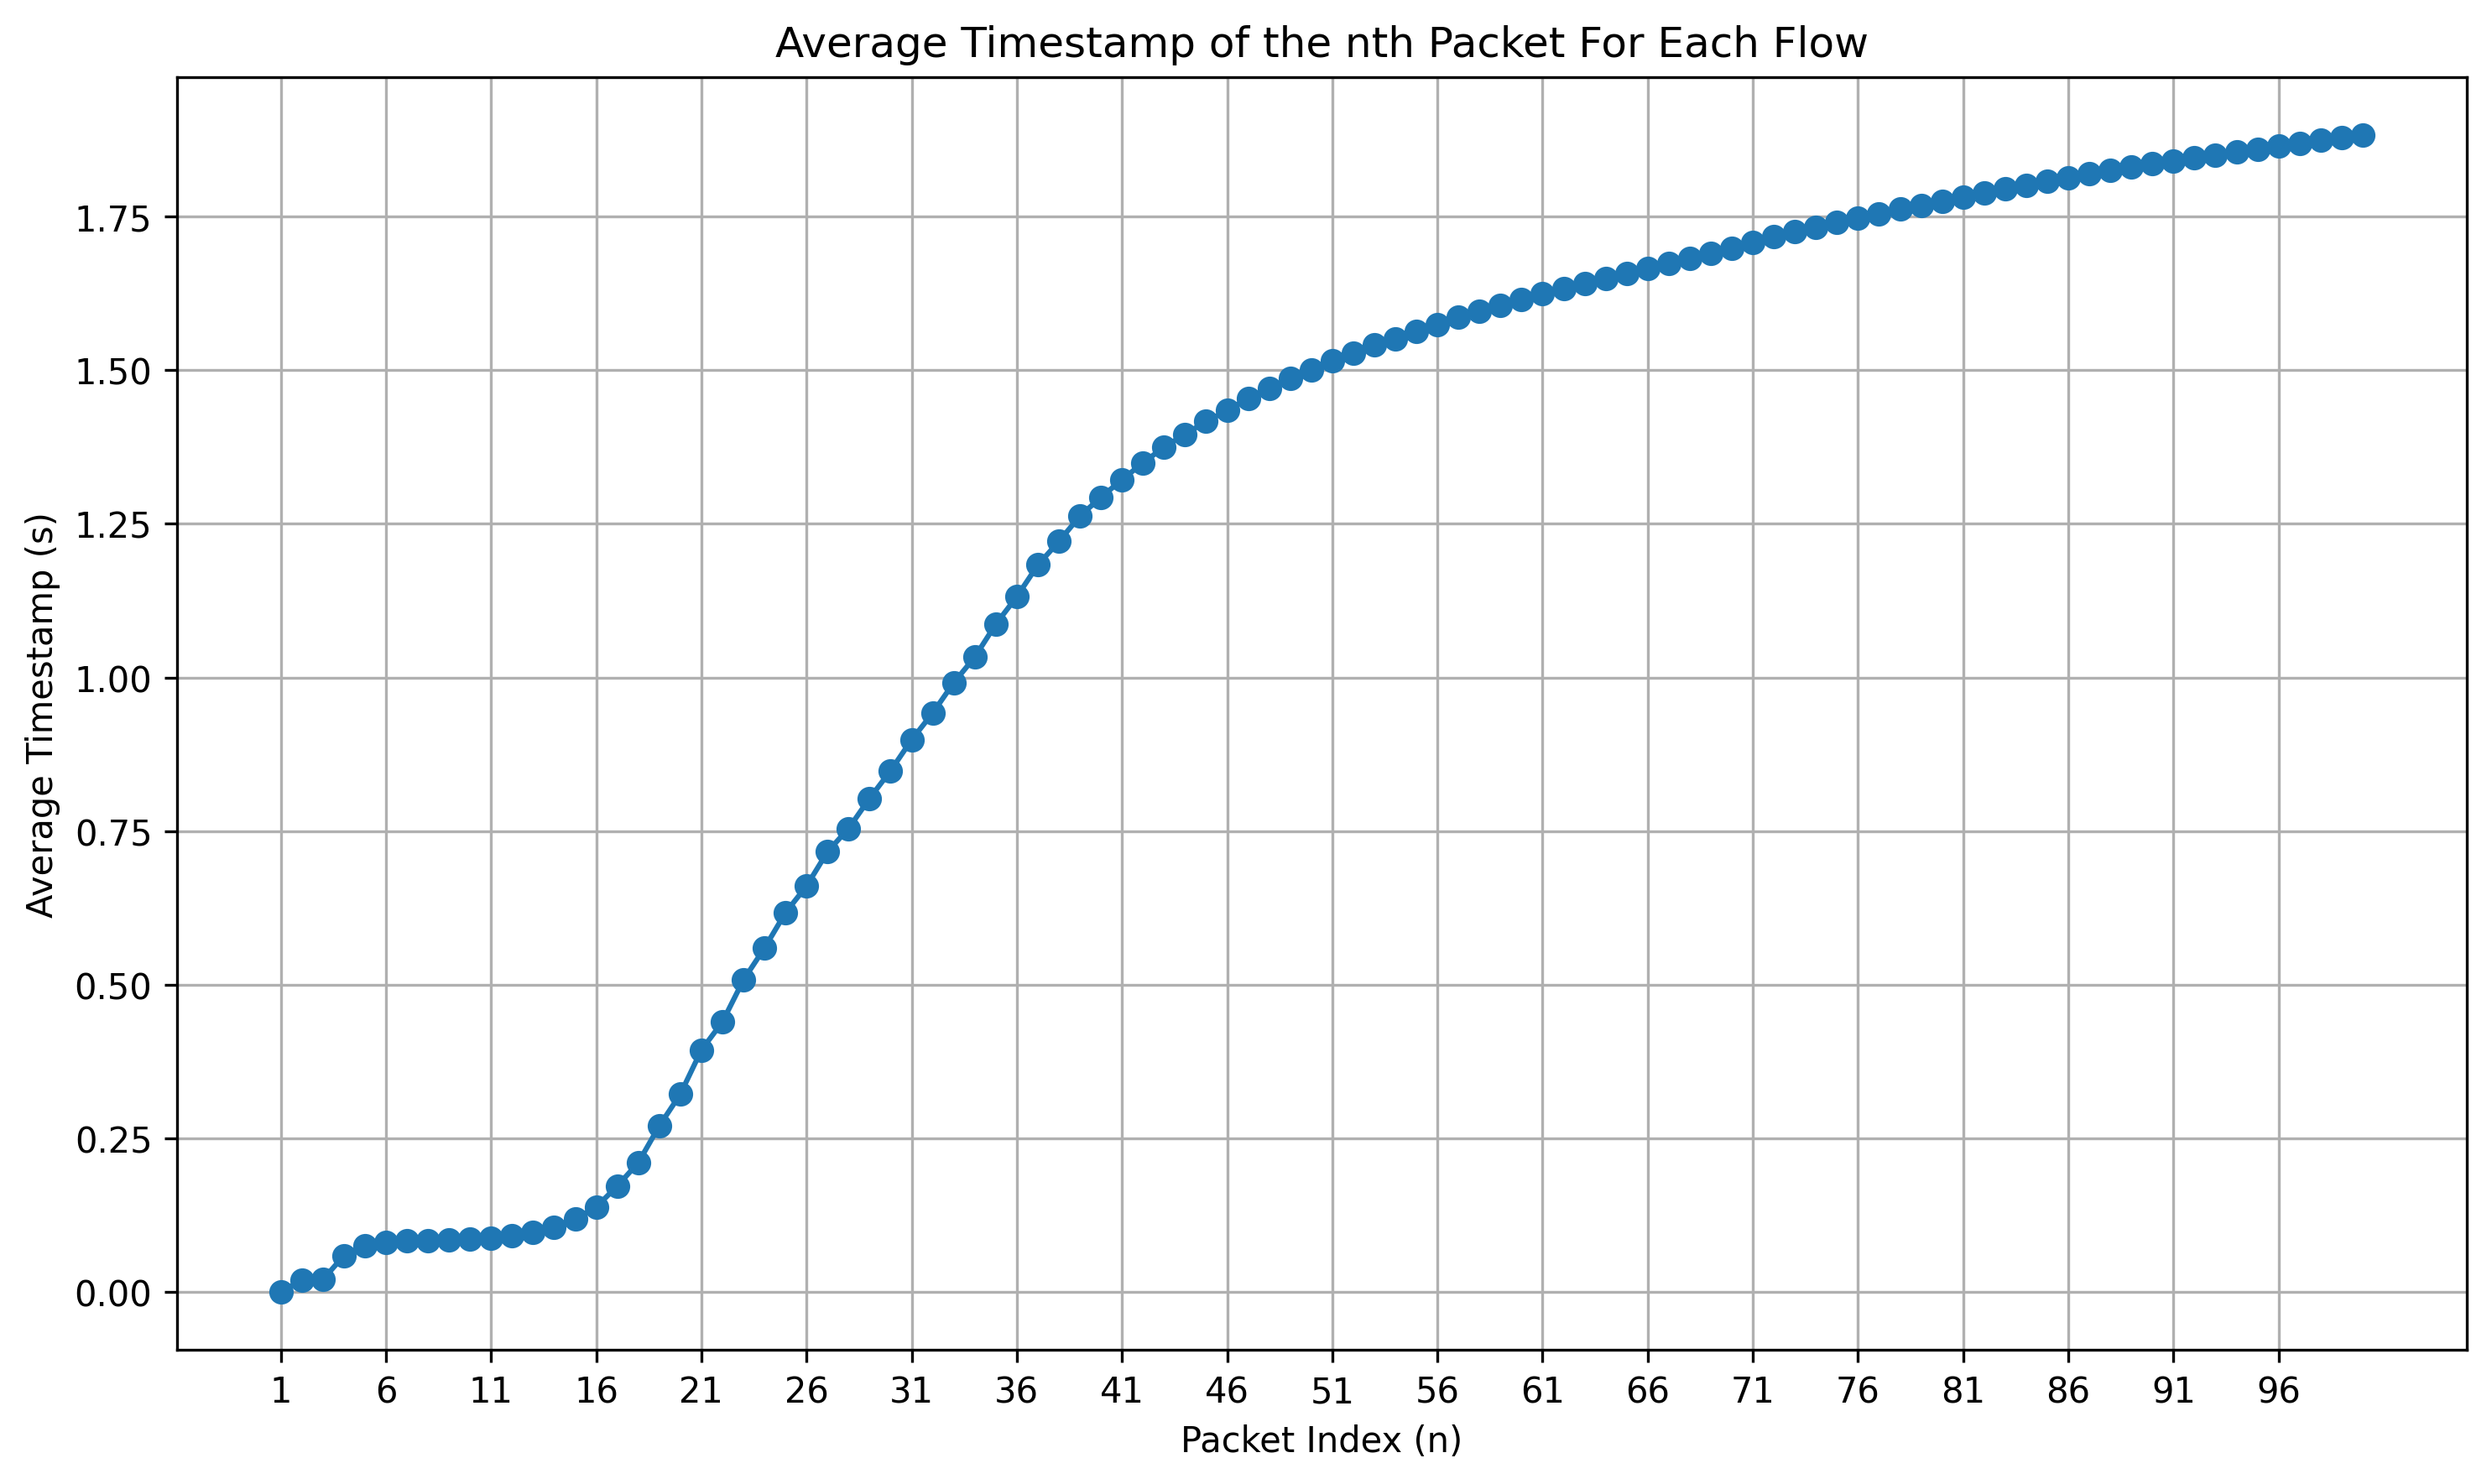

In [ ]:
# CMUMUL 以及 Tatic 包等待时延计算
# 统计等待前 X 的包等待时延
csv_path = "/home/tyf/Project/Tantic/raw_feature/tatic_all_class/tatic_features.csv"
# format: f.write(f'{identifier},"{feature_str}",{label}\n')
from os import times

import pandas as pd
import numpy as np

df = pd.read_csv(csv_path, header=None, names=["identifier", "features", "label"])

identifiers = df["identifier"]
features = df["features"]

# 对 features 每一行都做字符串清洗 + 拆分
parsed_features = pd.Series(
    [np.fromstring(str(s).strip("[]"), sep=",", dtype=float) for s in features],
    index=features.index,
    name="parsed_features",
    dtype=object,
)

# x1, y1, timestamp1, x2, y2, timestamp2, ..., xN, yN, timestampN
timestamps_diff = pd.Series(
    [arr[2::3] for arr in parsed_features],
    index=parsed_features.index,
    name="timestamps",
    dtype=object,
)  # 每个样本的时间戳序列

# 差分数组转换
timestamps = pd.Series(
    [np.cumsum(np.asarray(diff, dtype=float)) for diff in timestamps_diff],
    index=timestamps_diff.index,
    name="timestamps",
    dtype=object,
)

print(timestamps.shape)
print("样本数:", len(parsed_features))


# 统计每个样本
def get_nth_timestamp(timestamps_series, n):
    nth_timestamps = []
    for ts_list in timestamps_series:
        if len(ts_list) >= n:
            nth_timestamps.append(ts_list[n - 1])  # n-1 因为索引从0开始
        else:
            nth_timestamps.append(np.nan)  # 不足 n 个包时用 NaN 填充
    return pd.Series(
        nth_timestamps, index=timestamps_series.index, name=f"timestamp_{n}"
    )


for i in [4, 16, 20, 100]:
    timestamp_n = get_nth_timestamp(timestamps, i)
    print(f"第 {i} 个包的时间戳统计值:")
    print(timestamp_n.mean())
    print("------------------------------")

# 从 1 到 100 包的时间戳统计值
timestamp_stats = {}
for i in range(1, 101):
    timestamp_n = get_nth_timestamp(timestamps, i)
    timestamp_stats[i] = timestamp_n.mean()

# draw line plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6), dpi=300)
plt.plot(list(timestamp_stats.keys()), list(timestamp_stats.values()), marker="o")
plt.xlabel("Packet Index (n)")
plt.ylabel("Average Timestamp (s)")
plt.title("Average Timestamp of the nth Packet For Each Flow")
plt.grid(True)
plt.xticks(range(1, 101, 5))
plt.tight_layout()
plt.savefig("figure.svg", format="svg", bbox_inches="tight")
plt.show()

In [15]:
# 计算 mfts 的包等待时延
import numpy as np
import pandas as pd

file_path = "/home/tyf/Project/Tantic/raw_feature/tatic_all_class_2/tatic_features.csv"
df = pd.read_csv(
    file_path, header=None, names=["identifier", "features", "label", "flow_start_time"]
)

# 按照 identifier.split("_")[0] 分组
df["group"] = df["identifier"].apply(lambda x: x.split("_")[0])
df["flow_start_time"] = pd.to_numeric(df["flow_start_time"], errors="coerce")

# 先在组内按 flow_start_time 升序，再每组保留前 32 行数据（ 32条流）
grouped = (
    df.sort_values(["group", "flow_start_time"], ascending=[True, True])
    .groupby("group", sort=False, as_index=False)
    .head(32)
    .reset_index(drop=True)
)

# 转换 "features" 列为数值数组
grouped["parsed_features"] = grouped["features"].apply(
    lambda s: pd.to_numeric(str(s).strip("[]").split(","), errors="coerce").tolist()
)

# 提取时间差分并截取前20个， 每条流前 20 个包
grouped["timestamps_diff"] = grouped["parsed_features"].apply(
    lambda arr: np.asarray(arr[2::3], dtype=float)[:20]
)

# 逐行计算绝对时间戳：flow_start_time + 累计时间差分
grouped["timestamps"] = grouped.apply(
    lambda row: row["flow_start_time"] + np.cumsum(row["timestamps_diff"]), axis=1
)

wait_times = []

# 遍历每个组，取该组首样本首时间戳与末样本末时间戳之差
for group_name, group_data in grouped.groupby("group", sort=False):
    # print(f"组: {group_name}")
    first_sample_timestamps = group_data.iloc[0]["timestamps"][0]
    last_sample_timestamps = group_data.iloc[-1]["timestamps"][-1]
    wait_times.append(last_sample_timestamps - first_sample_timestamps)

assert len(wait_times) == len(grouped["group"].unique())
print(pd.Series(wait_times).describe())

mean = np.mean(wait_times)

# 这里 fusion 在 0.99 的置信度下得到的 Cov 为 45.52%
cov = 0.4552
stc_gf_ret = mean
mfts_ret = cov * 1 + (1 - cov) * mean
print(f"STC-GF: {stc_gf_ret}")
print(f"MFTS: {mfts_ret}")
print(f"减少百分比: {(mean - mfts_ret) / mean * 100:.2f}%")

count    11397.000000
mean         6.009518
std          5.049692
min          0.021394
25%          2.474421
50%          4.852733
75%          8.098785
max         66.921215
dtype: float64
STC-GF: 6.0095177634176355
MFTS: 3.7291852775099277
减少百分比: 37.95%
